In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as tt
import tqdm 
from tqdm import tqdm

np.random.seed(42)

### Experimental setup:
 - We consider random fully-connected feedforward networks with two hidden layers and ReLU activations, whose weights and biases are drawn i.i.d. from Gaussian distributions — $w_{i,j}^{(\mu)} \sim \mathcal{N}(0, \hat{C}_w / H_{\mu-1})$ and $b_i^{(\mu)} \sim \mathcal{N}(0, C_b)$ — with $\hat{C}_w = 0.8$ and $C_b = 0.2$. We don't train the networks on any data as the goal here is to study the priors and their convergence to GP. 
 - To measure how close this prior is to a Gaussian process, we use the unbiased estimator of the Maximum Mean Discrepancy with an RBF kernel, computed between 500 samples drawn from the network prior and $N=500$ samples drawn from the theoretical GP limit. 
 - All experiments use 10 input points drawn i.i.d. from $\mathcal{N}(0, I_4)$, so each sample is a vector in $\mathbb{R}^{10}$ representing a function evaluated at these fixed points. Each MMD² estimate is averaged over 10 independent repetitions to reduce variance. 

# I- Bottleneck experiments

In this code, we reproduce the experiments of the section 4 of the paper. We will plot the evolution of the MMD between the neural network output and samples of the corresponding gaussian process distribution, when increasing the number of hidden layers. 


In [4]:
C_W_HAT  = 0.8   # variance des poids (normalisée)
C_B      = 0.2   # variance des biais
D_IN     = 4     # dimension des entrées
N_INPUTS = 10    # nombre de points d'entrée
N_SAMPLES = 500  # nb d'échantillons par run (papier : 2000)
N_REPEATS = 20   # nb de répétitions pour estimer la variance (papier : 20)
LS = 0.5         # longueur d'échelle du noyau RBF pour l'estimateur MMD

In [5]:
# functions that define the GP kernel 

def relu_kernel_step(K, cw, cb):
    """
    Une étape de la récursion du noyau GP pour un réseau ReLU.
    K : matrice de covariance de la couche précédente (n x n).
    """
    n = K.shape[0]
    Kn = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            kii, kjj, kij = K[i, i], K[j, j], K[i, j]
            denom = np.sqrt(max(kii * kjj, 1e-14))
            cos_theta = np.clip(kij / denom, -1, 1)
            theta = np.arccos(cos_theta)
            J = (np.sin(theta) + (np.pi - theta) * cos_theta) / (2 * np.pi)
            Kn[i, j] = cw * np.sqrt(kii * kjj) * J  + cb
    return Kn


def gp_kernel(X, depth, cw=C_W_HAT, cb=C_B):
    """
    Calcule la matrice de noyau GP pour un réseau ReLU de profondeur `depth`.
    X : (n_pts, d_in)
    """
    K = cw * (X @ X.T) / X.shape[1] + cb   # noyau linéaire à la couche 0
    for _ in range(depth):
        K = relu_kernel_step(K, cw, cb)
    return K


In [6]:
# functions that sample the GP and the NN

def sample_gp(X, depth, ns, cw=C_W_HAT, cb=C_B):
    """
    samples ns functions of the GP prior and evaluates them in point X
    returns a table of size n x len(X)
    """
    K = gp_kernel(X, depth, cw, cb) + 1e-6 * np.eye(len(X))   
    L = np.linalg.cholesky(K)
    return (L @ np.random.randn(len(X), ns)).T   # (ns, len(X))


def sample_nn(X, sizes, ns, cw=C_W_HAT, cb=C_B, activation='relu'):
    """
    samples ns random networks and evaluate them in the point X 
    activation function = relu for envelope property, quadratic otherwise
    """
    layer_sizes = [X.shape[1]] + list(sizes) + [1]
    H = np.tile(X[None], (ns, 1, 1))   # (ns, n_pts, d_in)

    for l in range(len(layer_sizes) - 1):
        fin, fout = layer_sizes[l], layer_sizes[l + 1]
        W = np.random.randn(ns, fout, fin) * np.sqrt(cw / fin)  # (ns, fout, fin)
        b = np.random.randn(ns, 1, fout) * np.sqrt(cb)          # (ns, 1, fout)
        H = np.einsum('noi,npi->npo', W, H) + b                 # (ns, n_pts, fout)
        if l < len(layer_sizes) - 2:
            if activation == 'relu':
                H = np.maximum(H, 0)
            elif activation == 'quad':
                H = H ** 2  
    return H[:, :, 0]   # (ns, len(X))

Given $\{x_i\}_{i=1}^m \sim P$ et $\{y_j\}_{j=1}^n \sim Q$, the unbiased MMD estimator that we use is given by: 

$$
\widehat{\text{MMD}}^2(P, Q) = \frac{1}{m(m-1)} \sum_{i \neq i'} k(x_i, x_{i'}) + \frac{1}{n(n-1)} \sum_{j \neq j'} k(y_j, y_{j'}) - \frac{2}{mn} \sum_{i=1}^m \sum_{j=1}^n k(x_i, y_j)
$$


In [7]:
#functions that compute the MMD
def rbf_kernel(A, B, ls=LS):
    """RBF kernel matrix for 2 samples A,B"""
    diff = A[:, None] - B[None]               # (m, n, d)
    return np.exp(-np.sum(diff ** 2, axis=-1) / (2 * ls ** 2))


def mmd2_unbiased(X, Y):
    """
    computes the unbiased MMD^2(P,Q) estimator from samples X ~ P, Y ~ Q.
    X, Y : (n_samples, d)
    """
    all_samples = np.vstack([X, Y])
    dists = np.sum((all_samples[:, None] - all_samples[None])**2, axis=-1)
    ls = np.sqrt(np.median(dists[dists > 0]) / 2)
    
    m, n = len(X), len(Y)
    Kxx = rbf_kernel(X, X, ls); np.fill_diagonal(Kxx, 0)
    Kyy = rbf_kernel(Y, Y, ls); np.fill_diagonal(Kyy, 0)
    Kxy = rbf_kernel(X, Y, ls)
    return Kxx.sum()/(m*(m-1)) + Kyy.sum()/(n*(n-1)) - 2*Kxy.mean()

In [8]:
#function that produces the results


def run_sweep(X, depth, sizes_fn, n_values, activation='relu'):
    means, stds = [], []
    for n in tqdm(n_values):
        sizes = [min(s, 1500) for s in sizes_fn(n)]
        vals = []
        for _ in range(N_REPEATS):
            nn_s = sample_nn(X, sizes, N_SAMPLES, activation=activation)
            gp_s = sample_gp(X, depth, N_SAMPLES)
            # Normalisation par l'écart-type global avant MMD
            scale = np.std(np.vstack([nn_s, gp_s]))
            vals.append(mmd2_unbiased(nn_s / scale, gp_s / scale))
        means.append(np.mean(vals))
        stds.append(np.std(vals) / np.sqrt(N_REPEATS))
    return np.array(means), np.array(stds)

In [11]:
#generating data
X = np.random.randn(N_INPUTS, D_IN)   # 10 points en dimension 4 (i.i.d. N(0,1))
depth = 2                              # 2 couches cachées pour toutes les expériences

In [126]:
def asym_fn_slower(n):
    h1 = max(1, int(np.sqrt(n/5)))  # bottleneck, croissance lente
    h2 = n**2                      # croissance rapide
    return [h1, h2]

ns = list(range(1, 31))  
m_asym_slow, s_asym_slow = run_sweep(X, depth, asym_fn_slower, ns)

100%|██████████| 30/30 [06:04<00:00, 12.14s/it]


In [ ]:



def sym_fn(h):
    return [h, h]


def asym_fn(n):
    h1 = max(1, int(np.sqrt(n)))  # bottleneck, croissance lente
    h2 = n**2                      # croissance rapide
    return [h1, h2]


# Pour aligner les abscisses sur h1 :
ns = list(range(1, 31))                           # h1 = n

m_sym, s_sym = run_sweep(X, depth, sym_fn, ns)
m_asym, s_asym = run_sweep(X, depth, asym_fn, ns)


100%|██████████| 30/30 [06:20<00:00, 12.68s/it]


In [101]:
def asym_fn_exp(h):
    # h1 = h (bottleneck, croissance linéaire)
    # h2 = exp(h/5) (croissance exponentielle, sans cap nécessaire)
    return [h, int(np.exp(h / 5))]

ns = list(range(1, 31))          
# m_sym, s_sym = run_sweep(X, depth, sym_fn, ns)
m_asym_exp, s_asym_exp = run_sweep(X, depth, asym_fn_exp, ns)



100%|██████████| 30/30 [06:00<00:00, 12.02s/it]


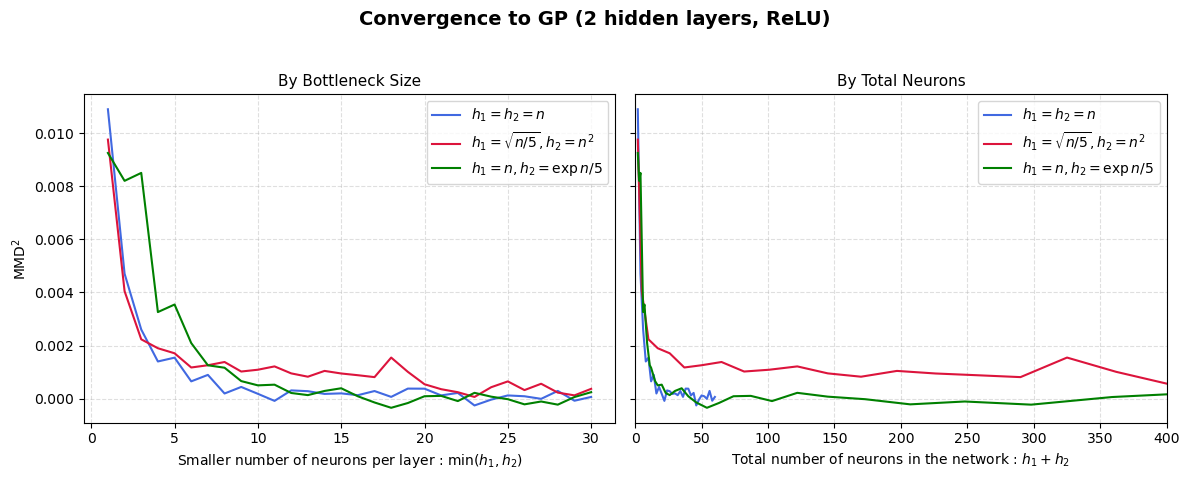

In [128]:
# Augmentation de la largeur pour éviter l'écrasement
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# --- Titre global (évite la répétition sur chaque plot) ---
fig.suptitle('Convergence to GP (2 hidden layers, ReLU)', fontsize=14, fontweight='bold')

# --- Plot 1: Bottleneck ---
ax0.plot(ns, m_sym, color='royalblue', lw=1.5, ms=4, label=r'$h_1=h_2=n$')
ax0.plot(ns, m_asym_slow, color='crimson',   lw=1.5, ms=4, label=r'$h_1=\sqrt{n/5}, h_2=n^2$')
ax0.plot(ns,m_asym_exp,color = 'green',lw=1.5, ms=4, label=r'$h_1=n, h_2=\exp{n/5}$')


ax0.set_title('By Bottleneck Size', fontsize=11)
ax0.set_xlabel('Smaller number of neurons per layer : min($h_1, h_2$)')
ax0.set_ylabel(r'MMD$^2$')
ax0.grid(True, ls='--', alpha=0.4)
# Place la légende à droite de l'axe 0
ax0.legend()

# --- Plot 2: Total Capacity ---

x_sym   = [2*n for n in ns]                          # total = 2n
x_asym  = [asym_fn_slower(n)[0] + asym_fn_slower(n)[1] for n in ns]  # total = sqrt(n) + n²
x_asym_exp = [asym_fn_exp(n)[0] + asym_fn_exp(n)[1] for n in ns]  


ax1.plot(x_sym,  m_sym, color='royalblue', lw=1.5, ms=4, label='$h_1=h_2=n$')
ax1.plot(x_asym, m_asym_slow, color='crimson',   lw=1.5, ms=4, label='$h_1=\sqrt{n/5}, h_2=n^2$')
ax1.plot(x_asym_exp,m_asym_exp,color = 'green',lw=1.5, ms=4, label=r'$h_1=n, h_2=\exp{n/5}$')
ax1.grid(True, ls='--', alpha=0.4)
ax1.set_title('By Total Neurons', fontsize=11)
ax1.set_xlabel(r'Total number of neurons in the network : $h_1 + h_2$')
ax1.set_xlim(0, 400)
ax1.legend()


# --- Style commun ---
# for a in [ax0, ax1]:
#     a.grid(True, which="both", ls='--', alpha=0.5)
#     a.spines[['top', 'right']].set_visible(False)
#     a.legend(frameon=False, fontsize=9)
    # Optionnel : décommentez si la décroissance est rapide
    # a.set_yscale('log')
    # a.set_yscale('log')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste pour le suptitle
plt.show()

In the figure above:
- The blue curve represents the MMD between a network where the number of neurons in each layer grows at a rate n and the limit GP. We will refer to this network as the symetric network. 
- The red curve represents the MMD between the limiting GP and a network where the number of neurons in the first layer grows at a rate $\sqrt{n/5}$ and the number of neurons in the second layer grows at rate $n^2$. We will refer to this network as the sqrt/polynomial network.  
- The green curve represents the MMD between the limiting GP and a network where the number of neurons in the first layer grows at a rate $n$ and the number of neurons in the second layer grows at rate $\exp(n/5)$. We will refer to this network as the linear/exponential network.

The left panel represents convergence of each neural network to their limiting GP by narrowest layer size (bottleneck). All three curves converge at roughly the same rate when aligned on the bottleneck. This shows that what governs convergence to the GP is only the width of the narrowest layer, regardless of how wide other layers are. At bottleneck size 20, ie if all networks have a narrowest layer with 20 neurons, the symmetric network has 20+20=40 total neurons, the sqrt/polynomial network has $\sqrt{20/5} + 20^2 = 402$ neurons, and the linear/exponential network has $20 + \exp(20/5) \approx 75$ neurons — yet all three have the same MMD² value. This shows that extra neurons in the wider layers are irrelevant to convergence speed and that what matters is the width of the bottleneck.

The right panel represents convergence of each neural network to their limiting GP by total number of neurons in the network. The For a fixed budget of total neurons, the red curve converges much more slowy to zero than the green and blue ones. For a fixed budget of 400 neurons in the network, there are $\sim 4$ neurons in the bottleneck layer of the sqrt/polynomial network. We can also see that the symetric network and the linear/exponential network converge at the same rate, so that growing the width of the second layer at an exponential rate is useless. This shows that the number of neurons is not what matters. It is rather the distribution of neurons across layers which matters: a network with thousands of neurons but with a bottleneck layer width of 5 will not converge faster than a network with 10 neurons per layer. 

These plots show that when computational power is limited, if we want to approximate GP with neural network, it is better to grow all layers uniformly than to put too many neurons in already wide layers.



# II- Convergence speed to the GP

In [ ]:
results_alpha = {}

In [139]:

alphas = np.arange(0.25,2.75,0.25)
n_fixed_values = [5,10,15]   

for n_fixed in n_fixed_values:
    means, stds = [], []
    for alpha in tqdm(alphas):
        h = max(1, int(n_fixed ** alpha))
        vals = [mmd2_unbiased(sample_nn(X, [h, h], N_SAMPLES),
                              sample_gp(X, depth, N_SAMPLES))
                for _ in range(N_REPEATS)]
        means.append(np.mean(vals))
        stds.append(np.std(vals) / np.sqrt(N_REPEATS))
    results_alpha[n_fixed] = (np.array(means), np.array(stds))


100%|██████████| 10/10 [10:30<00:00, 63.03s/it] 


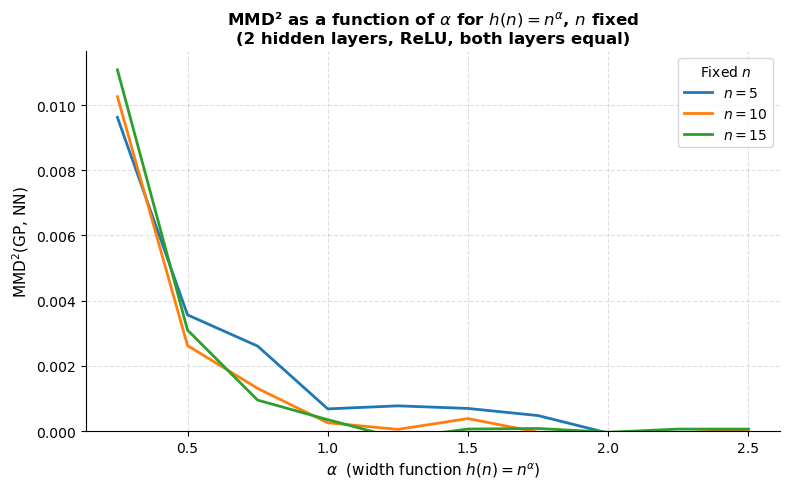

In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))

for n_fixed in [5,10,15]:
    (m,s) = results_alpha[n_fixed]
    # h_values = [min(2000, max(1, int(n_fixed**alpha))) for alpha in alphas]
    ax.plot(alphas, m[:len(alphas)], lw=2, ms=3.5, label=f'$n={n_fixed}$')
    # ax.fill_between(alphas, m - s, m + s, color=color, alpha=0.15)


ax.set_xlabel(r'$\alpha$  (width function $h(n) = n^\alpha$)', fontsize=11)
ax.set_ylabel(r'MMD$^2$(GP, NN)', fontsize=11)
ax.set_title(r'MMD² as a function of $\alpha$ for $h(n)=n^\alpha$, $n$ fixed'
             '\n(2 hidden layers, ReLU, both layers equal)',
             fontweight='bold')
ax.legend(title='Fixed $n$', fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(True, ls='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In the figure above, we fix the sequence index $n$ to three values ($n=5,10,15$) and vary the exponent $\alpha \in [0.1,2.5]$ of the width function $h(n) = n^{\alpha}$, which controls how many hidden units each layer contains. For each pair $(n,\alpha)$ both hidden layers have exactly $n^{\alpha}$ units, and we measure MMD² between 500 samples from the resulting random network prior and 500 samples from the theoretical GP limit. The figure shows that: 
- for each value of $n$, the curves have similar shapes. This shows that the convergence of the network to its limit GP is governed by the width $n^{\alpha}$ and not by $n$ and $\alpha$ separately. 
- the curve decreases steeply to zero for $\alpha \in [0.1,1]$ and then becomes almost flat for $\alpha > 1$. Hence, for the network to converge to a GP, and for a fixed $n$, increasing the number of neurons at rate $n$ is usually enough to get a fast convergence rate to the limit GP. 
- regardless of the combination of $n$ and $\alpha$, convergence is achieved quickly and MMD becomes very close to zero even for a small number of neurons per layers like 10 or 20. 



# III- Violating the Linear Envelope Property assumption

In the paper, the activation functions φ are assumed to satisfy the Linear envelope property (LEP), ie |φ(u)| ≤ c + m|u|. We will see if convergence to a GP still holds for activation functions that do not satisfy the LEP property. 
 - φ(u) = u²        
 - φ(u) = exp(u/4)  
 - φ(u) = u³        

In [130]:


def sample_nn_activation(X, sizes, ns, phi):
    """Forward pass with an arbitrary activation function phi."""
    layer_sizes = [X.shape[1]] + list(sizes) + [1]
    H = np.tile(X[None], (ns, 1, 1))
    for l in range(len(layer_sizes) - 1):
        fin, fout = layer_sizes[l], layer_sizes[l + 1]
        W = np.random.randn(ns, fout, fin) * np.sqrt(C_W_HAT / fin)
        b = np.random.randn(ns, 1, fout) * np.sqrt(C_B)
        H = np.einsum('noi,npi->npo', W, H) + b
        if l < len(layer_sizes) - 2:
            H = phi(H)
    return H[:, :, 0]

def run_sweep_phi(X, depth, hs, phi):
    means, stds = [], []
    for h in tqdm(hs):
        vals = []
        for _ in range(N_REPEATS):
            nn_s = sample_nn_activation(X, [h, h], N_SAMPLES, phi)
            # Clip pour éviter les explosions numériques (exp, u³)
            # nn_s = np.clip(nn_s, -1e4, 1e4)
            gp_s = sample_gp(X, depth, N_SAMPLES)
            vals.append(mmd2_unbiased(nn_s, gp_s))
        means.append(np.mean(vals))
        stds.append(np.std(vals) / np.sqrt(N_REPEATS))
    return np.array(means), np.array(stds)

hs_lep = list(range(1, 31))

activations = {
    r'ReLU  $\phi(u)=\max(u,0)$ ' : lambda u: np.maximum(u, 0),
    r'$\phi(u)=u^2$'             : lambda u: u**2,
    r'$\phi(u)=e^{u/4}$'         : lambda u: np.exp(np.clip(u/4, -10, 10)),
    r'$\phi(u)=u^3$'             : lambda u: u**3,
}
colors = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']

results = {}
for name, phi in activations.items():
    results[name] = run_sweep_phi(X, depth, hs_lep, phi)


100%|██████████| 30/30 [05:36<00:00, 11.22s/it]


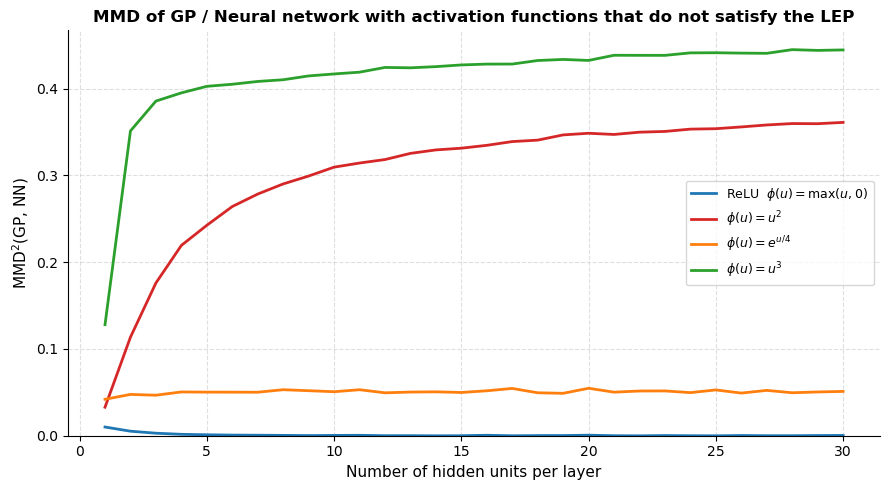

In [131]:

fig, ax = plt.subplots(figsize=(9, 5))

for (name, (m, s)), color in zip(results.items(), colors):
    ax.plot(hs_lep, m, color=color, lw=2, ms=3.5, label=name)
    # ax.fill_between(hs_lep, m - s, m + s, color=color, alpha=0.15)

ax.set_xlabel('Number of hidden units per layer', fontsize=11)
ax.set_ylabel(r'MMD$^2$(GP, NN)', fontsize=11)
ax.set_title('MMD of GP / Neural network with activation functions that do not satisfy the LEP', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(tt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.grid(True, ls='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


The convergence of the network to a Gaussian process requires the activation function to satisfy the linear envelope property (LEP). This sufficient condition allows an inductive proof through the layers: at each layer, the pre-activations are a weighted sum of exchangeable terms, and the LEP ensures that the absolute third moment of these terms grows slower than a given rate​, which is precisely the condition needed to apply the exchangeable CLT. When the LEP is violated, this inductive argument breaks down: the moments of each layer depend on higher-order moments of the previous layer, which will result in divergence. 

This figure illustrates the fact that LEP is a sufficient condition that allows for convergence. The plot represents the MMD of neural networks with several activation functions and their limiting GP. We can see that the network with a ReLu activation function converges to its limiting GP because it satisfies the LEP. On the contrary, the networks with a polynomial or exponential activation function converge to a non-gaussian limit because the activation functions used.

# IV- Non-Gaussian weight priors

The paper assumes Gaussian weight priors (Equations 4-5). We test whether the convergence to the GP limit still holds when the weights are drawn from other distributions with the same variance. Since the CLT applies regardless of the weight distribution (as long as the variance is finite), the network should still converge to *a* GP — but the limiting kernel may differ from the Cho-Saul kernel, which assumes Gaussianity. We compare the network to the Cho-Saul GP to measure this discrepancy.


In [9]:
from scipy import stats as sp_stats

def sample_weights(shape, variance, prior='gaussian'):
    """
    Sample a weight matrix of given shape with mean 0 and given variance,
    from the specified prior distribution.
    """
    if prior == 'gaussian':
        return np.random.randn(*shape) * np.sqrt(variance)

    elif prior == 'uniform':
        # Uniform(-a, a), Var = a^2/3 = variance
        a = np.sqrt(3 * variance)
        return np.random.uniform(-a, a, size=shape)

    elif prior == 'laplace':
        # Laplace(0, b), Var = 2b^2 = variance
        b = np.sqrt(variance / 2)
        return np.random.laplace(0, b, size=shape)

    elif prior == 'student5':
        # Student-t(5), Var = 5/3 * scale^2 = variance
        scale = np.sqrt(variance * 3 / 5)
        return sp_stats.t.rvs(5, scale=scale, size=shape)

    elif prior == 'rademacher':
        # +/- sqrt(variance) with prob 1/2
        return np.sqrt(variance) * (2 * np.random.randint(0, 2, size=shape) - 1).astype(float)

    elif prior == 'blundell':
        # Scale mixture: 0.5 * N(0, 1.8*var) + 0.5 * N(0, 0.2*var)
        # Overall Var = 0.5*1.8*var + 0.5*0.2*var = variance
        mask = np.random.random(shape) < 0.5
        return np.where(mask,
                        np.random.randn(*shape) * np.sqrt(1.8 * variance),
                        np.random.randn(*shape) * np.sqrt(0.2 * variance))
    else:
        raise ValueError(f"Unknown prior: {prior}")


def sample_nn_prior(X, sizes, ns, cw=C_W_HAT, cb=C_B, prior='gaussian'):
    """
    Sample ns random networks with weights from a given prior distribution.
    Biases remain Gaussian. Activation = ReLU.
    """
    layer_sizes = [X.shape[1]] + list(sizes) + [1]
    H = np.tile(X[None], (ns, 1, 1))

    for l in range(len(layer_sizes) - 1):
        fin, fout = layer_sizes[l], layer_sizes[l + 1]
        W = sample_weights((ns, fout, fin), cw / fin, prior=prior)
        b = np.random.randn(ns, 1, fout) * np.sqrt(cb)
        H = np.einsum('noi,npi->npo', W, H) + b
        if l < len(layer_sizes) - 2:
            H = np.maximum(H, 0)
    return H[:, :, 0]

In [12]:
def run_sweep_prior(X, depth, hs, prior='gaussian'):
    """Run MMD sweep comparing NN with given weight prior to the Cho-Saul GP."""
    means, stds = [], []
    for h in tqdm(hs):
        vals = []
        for _ in range(N_REPEATS):
            nn_s = sample_nn_prior(X, [h, h], N_SAMPLES, prior=prior)
            gp_s = sample_gp(X, depth, N_SAMPLES)
            scale = np.std(np.vstack([nn_s, gp_s]))
            if scale > 0:
                vals.append(mmd2_unbiased(nn_s / scale, gp_s / scale))
            else:
                vals.append(0.0)
        means.append(np.mean(vals))
        stds.append(np.std(vals) / np.sqrt(N_REPEATS))
    return np.array(means), np.array(stds)


hs_prior = list(range(1, 31))

prior_configs = {
    r'Gaussian (baseline)':  'gaussian',
    r'Uniform':              'uniform',
    r'Laplace':              'laplace',
    r'Student-$t$(5)':       'student5',
    r'Rademacher':           'rademacher',
    r'Blundell scale mix.':  'blundell',
}

results_prior = {}
for name, prior in prior_configs.items():
    print(f"Running {name}...")
    results_prior[name] = run_sweep_prior(X, depth, hs_prior, prior=prior)


Running Gaussian (baseline)...


100%|██████████| 30/30 [03:55<00:00,  7.86s/it]


Running Uniform...


100%|██████████| 30/30 [03:09<00:00,  6.32s/it]


Running Laplace...


...

100%|██████████| 30/30 [03:21<00:00,  6.70s/it]


Running Rademacher...


100%|██████████| 30/30 [03:27<00:00,  6.92s/it]


Running Blundell scale mix....


100%|██████████| 30/30 [03:53<00:00,  7.79s/it]


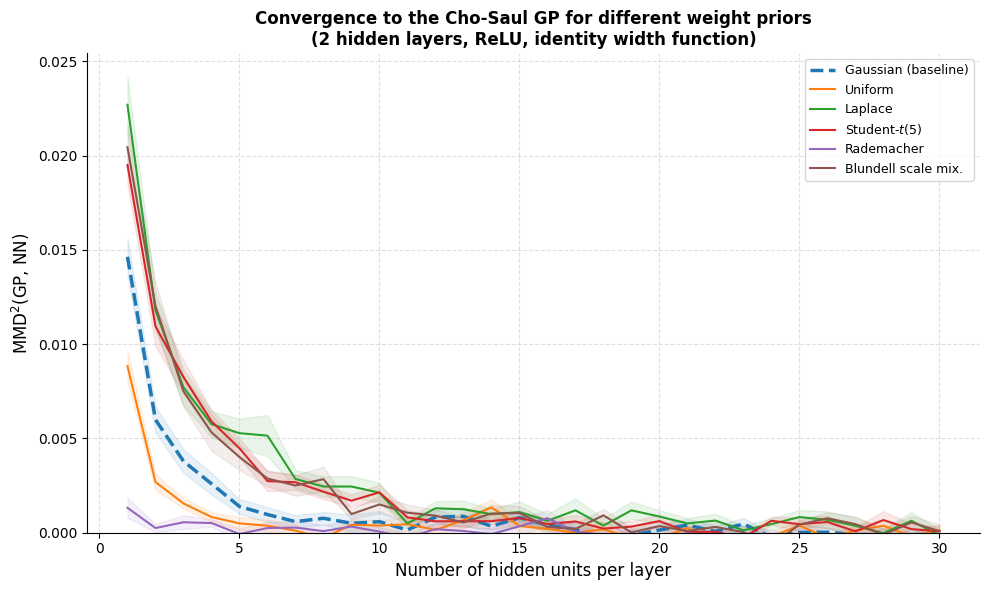

In [13]:
prior_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, ax = plt.subplots(figsize=(10, 6))

for (name, (m, s)), color in zip(results_prior.items(), prior_colors):
    lw = 2.5 if 'Gaussian' in name else 1.5
    ls = '--' if 'Gaussian' in name else '-'
    ax.plot(hs_prior, m, color=color, lw=lw, ls=ls, label=name)
    ax.fill_between(hs_prior, m - s, m + s, color=color, alpha=0.1)

ax.set_xlabel('Number of hidden units per layer', fontsize=12)
ax.set_ylabel(r'MMD$^2$(GP, NN)', fontsize=12)
ax.set_title(
    'Convergence to the Cho-Saul GP for different weight priors\n'
    '(2 hidden layers, ReLU, identity width function)',
    fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.grid(True, ls='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# V. Infinite-variance weight priors

When the weight distribution has **infinite variance**, the CLT no longer
applies and the scaling $C_w^{(\mu)} = \hat{C}_w / H_{\mu-1}$ no longer
stabilizes the activations. The network output does not converge to a GP
but to an **$\alpha$-stable process** (Peluchetti et al., 2020).

We test three infinite-variance distributions:
- **Cauchy** ($\alpha$-stable with $\alpha = 1$): no moments exist at all
- **Stable($\alpha = 1.5$)**: mean exists but variance is infinite
- **Pareto-tailed**: $P(|w| > t) \sim t^{-3}$, so $\mathbb{E}[w^2] = \infty$

We keep the same $1/H_{\mu-1}$ scaling on the weights, even though it is
not the correct scaling for stable laws. This means the MMD should
**not converge to zero** — and may even increase with width.

In [14]:

from scipy import stats as sp_stats

def sample_weights_heavy(shape, scale, prior='cauchy'):
    """
    Sample weights from infinite-variance distributions.
    'scale' controls the spread (analogous to sqrt(C_w/fan_in) for Gaussian).
    """
    if prior == 'cauchy':
        # Cauchy(0, scale): no moments at all
        return sp_stats.cauchy.rvs(loc=0, scale=scale, size=shape)

    elif prior == 'stable15':
        # alpha-stable with alpha=1.5, beta=0 (symmetric)
        # scipy parameterization: S(alpha, beta, loc, scale)
        return sp_stats.levy_stable.rvs(1.5, 0, loc=0, scale=scale, size=shape)

    elif prior == 'pareto_tailed':
        # Symmetric Pareto-tailed: w = sign * |t|  where t ~ Pareto(alpha=2)
        # P(|w| > x) ~ x^{-2}, so E[w^2] = infinity
        # We use Student-t(2) which has Var = infinity
        return sp_stats.t.rvs(2, scale=scale, size=shape)

    else:
        raise ValueError(f"Unknown prior: {prior}")


def sample_nn_heavy(X, sizes, ns, cw=C_W_HAT, cb=C_B, prior='cauchy'):
    """
    Sample ns random networks with infinite-variance weight priors.
    Uses the same 1/fan_in scaling as the paper (even though it's
    not the correct scaling for stable laws).
    """
    layer_sizes = [X.shape[1]] + list(sizes) + [1]
    H = np.tile(X[None], (ns, 1, 1))

    for l in range(len(layer_sizes) - 1):
        fin, fout = layer_sizes[l], layer_sizes[l + 1]
        scale = np.sqrt(cw / fin)  # same scaling as Gaussian case
        W = sample_weights_heavy((ns, fout, fin), scale, prior=prior)
        b = np.random.randn(ns, 1, fout) * np.sqrt(cb)
        H = np.einsum('noi,npi->npo', W, H) + b
        if l < len(layer_sizes) - 2:
            H = np.maximum(H, 0)  # ReLU

    # Clip extreme values to avoid numerical issues in MMD
    H = np.clip(H, -1e6, 1e6)
    return H[:, :, 0]

In [15]:
def run_sweep_heavy(X, depth, hs, prior='cauchy'):
    """Run MMD sweep for infinite-variance priors."""
    means, stds = [], []
    for h in tqdm(hs):
        vals = []
        for _ in range(N_REPEATS):
            nn_s = sample_nn_heavy(X, [h, h], N_SAMPLES, prior=prior)
            gp_s = sample_gp(X, depth, N_SAMPLES)
            scale = np.std(np.vstack([nn_s, gp_s]))
            if scale > 0:
                vals.append(mmd2_unbiased(nn_s / scale, gp_s / scale))
            else:
                vals.append(0.0)
        means.append(np.mean(vals))
        stds.append(np.std(vals) / np.sqrt(N_REPEATS))
    return np.array(means), np.array(stds)


hs_heavy = list(range(1, 31))

heavy_configs = {
    r'Gaussian (baseline)': None,         # reuse from before
    r'Cauchy ($\alpha=1$)': 'cauchy',
    r'Stable ($\alpha=1.5$)': 'stable15',
    r'Student-$t$(2) (Var$=\infty$)': 'pareto_tailed',
}

results_heavy = {}

# Gaussian baseline: reuse if available, otherwise recompute
if 'Gaussian (baseline)' in results_prior:
    results_heavy[r'Gaussian (baseline)'] = results_prior[r'Gaussian (baseline)']
else:
    print("Running Gaussian baseline...")
    results_heavy[r'Gaussian (baseline)'] = run_sweep_prior(X, depth, hs_heavy, prior='gaussian')

for name, prior in heavy_configs.items():
    if prior is None:
        continue
    print(f"Running {name}...")
    results_heavy[name] = run_sweep_heavy(X, depth, hs_heavy, prior=prior)

Running Cauchy ($\alpha=1$)...


100%|██████████| 30/30 [03:29<00:00,  6.97s/it]


Running Stable ($\alpha=1.5$)...


100%|██████████| 30/30 [05:51<00:00, 11.71s/it]


Running Student-$t$(2) (Var$=\infty$)...


100%|██████████| 30/30 [03:42<00:00,  7.40s/it]


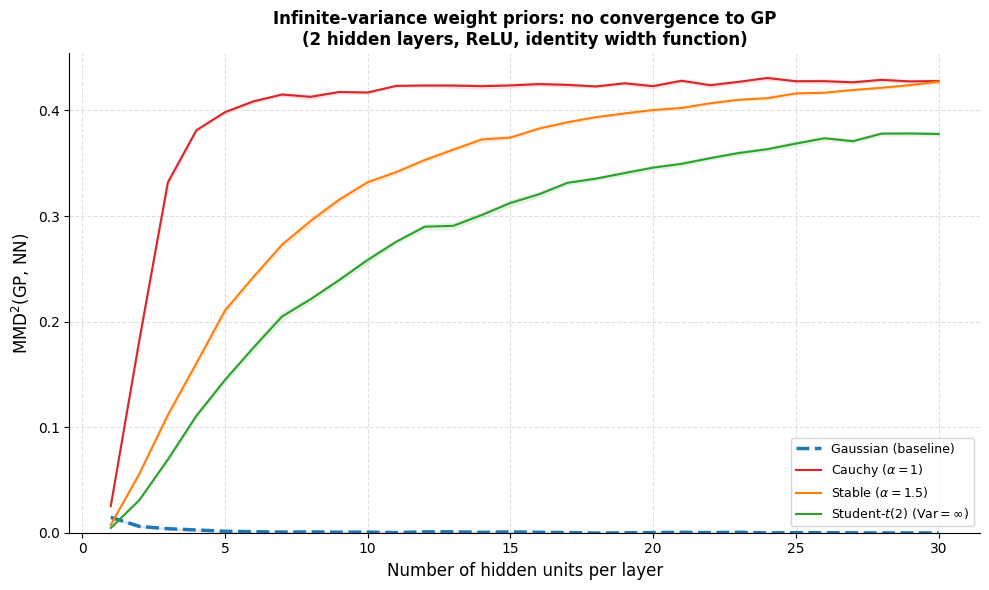

In [16]:
heavy_colors = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(10, 6))

for (name, (m, s)), color in zip(results_heavy.items(), heavy_colors):
    lw = 2.5 if 'Gaussian' in name else 1.5
    ls = '--' if 'Gaussian' in name else '-'
    ax.plot(hs_heavy, m, color=color, lw=lw, ls=ls, label=name)
    ax.fill_between(hs_heavy, m - s, m + s, color=color, alpha=0.1)

ax.set_xlabel('Number of hidden units per layer', fontsize=12)
ax.set_ylabel(r'MMD$^2$(GP, NN)', fontsize=12)
ax.set_title(
    'Infinite-variance weight priors: no convergence to GP\n'
    '(2 hidden layers, ReLU, identity width function)',
    fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)
ax.grid(True, ls='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:** Unlike the finite-variance priors, the infinite-variance
curves do **not** converge to zero. The MMD² remains elevated or even
increases with width, confirming that the GP limit breaks down entirely
when the weight variance is infinite. This is because:

1. The $1/H_{\mu-1}$ scaling assumes finite variance to stabilize
   activations — with infinite variance, the activations diverge.
2. The CLT does not apply: the sum $\sum_j w_j g_j$ converges to a
   **stable law**, not a Gaussian, so the network output converges to an
   $\alpha$-stable process, not a GP (Peluchetti et al., 2020).
3. The Cho-Saul kernel recursion is undefined because $\mathbb{E}[\varphi(z_1)\varphi(z_2)]$
   may not exist when $z_1, z_2$ have infinite variance.

This shows that the linear envelope property and Gaussian weight assumption
in Theorem 4 are not mere technical convenience — they are necessary to
ensure that the GP limit exists. Relaxing to finite-variance non-Gaussian
weights changes the kernel but preserves the GP structure; relaxing to
infinite-variance weights destroys it.

# VI Shallower networks and non-Gaussian weights priors



We test whether the number of hidden layers affects how quickly
the non-Gaussianity of the weight prior is washed out. With 1 
hidden layer, the CLT only acts once (layer 1 → output); with 
2 hidden layers, it acts twice and the kernel recursion further
attenuates any discrepancy.

In [17]:
# Sweep over depths 1 and 2 for each prior
depths_to_test = [1, 2]
hs_depth = list(range(1, 31))

results_depth = {}

for d in depths_to_test:
    for name, prior in prior_configs.items():
        key = f"{name} (D={d})"
        print(f"Running {key}...")
        means, stds = [], []
        for h in tqdm(hs_depth):
            sizes = [h] * d  # d layers of width h
            vals = []
            for _ in range(N_REPEATS):
                nn_s = sample_nn_prior(X, sizes, N_SAMPLES, prior=prior)
                gp_s = sample_gp(X, d, N_SAMPLES)
                scale = np.std(np.vstack([nn_s, gp_s]))
                if scale > 0:
                    vals.append(mmd2_unbiased(nn_s / scale, gp_s / scale))
                else:
                    vals.append(0.0)
            means.append(np.mean(vals))
            stds.append(np.std(vals) / np.sqrt(N_REPEATS))
        results_depth[key] = (np.array(means), np.array(stds))



Running Gaussian (baseline) (D=1)...


100%|██████████| 30/30 [02:48<00:00,  5.60s/it]


Running Uniform (D=1)...


100%|██████████| 30/30 [02:11<00:00,  4.37s/it]


Running Laplace (D=1)...


...

100%|██████████| 30/30 [03:55<00:00,  7.85s/it]


Running Rademacher (D=2)...


100%|██████████| 30/30 [02:26<00:00,  4.90s/it]


Running Blundell scale mix. (D=2)...


100%|██████████| 30/30 [03:18<00:00,  6.62s/it]


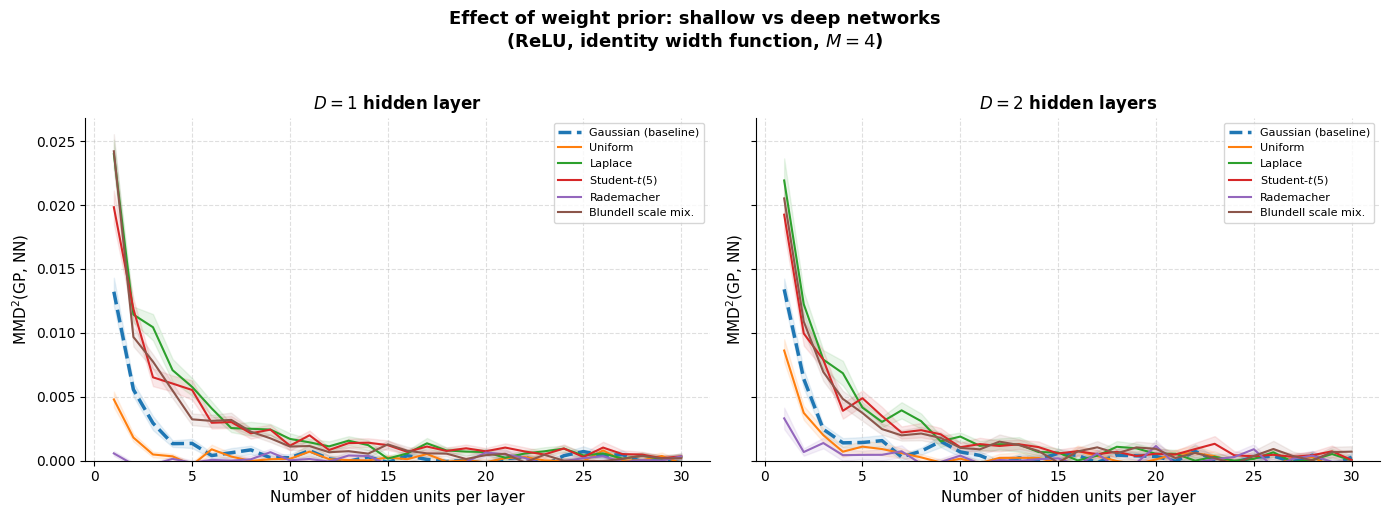

In [ ]:
# Plot: one subplot per depth, all priors overlaid
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for idx, d in enumerate(depths_to_test):
    ax = axes[idx]
    for (name, prior), color in zip(prior_configs.items(), prior_colors):
        key = f"{name} (D={d})"
        m, s = results_depth[key]
        lw = 2.5 if 'Gaussian' in name else 1.5
        ls = '--' if 'Gaussian' in name else '-'
        ax.plot(hs_depth, m, color=color, lw=lw, ls=ls, label=name)
        ax.fill_between(hs_depth, m - s, m + s, color=color, alpha=0.1)

    ax.set_xlabel('Number of hidden units per layer', fontsize=11)
    ax.set_ylabel(r'MMD$^2$(GP, NN)', fontsize=11)
    ax.set_title(f'$D = {d}$ hidden layer{"s" if d > 1 else ""}',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)
    ax.grid(True, ls='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Effect of weight prior: shallow vs deep networks\n'
             '(ReLU, identity width function, $M=4$)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



**Interpretation:** If the non-Gaussian prior has a detectable effect,
it should be larger for $D=1$ (where the CLT has acted only once) 
than for $D=2$ (where it has acted twice and the kernel recursion 
has further attenuated the discrepancy). If both panels look 
identical, it confirms that the effect is already negligible at 
$D=1$ for $M=4$.